In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ScikitLearn.MinMax_scalling import color_dict
from keras.src.utils.dataset_utils import labels_to_dataset_grain
from matplotlib import lines

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day36-imputing-numerical-data/titanic_toy.csv")

In [4]:
df.to_csv("titanic_toy.csv", index=False)

In [5]:
df.shape

(891, 4)

In [14]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [15]:
X = df.drop(columns=["Survived"])
y = df["Survived"]


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [20]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [21]:
mean_age = X_train["Age"].mean()
median_age = X_train["Age"].median()

mean_fare = X_train["Fare"].mean()
median_fare = X_train["Fare"].median()



In [23]:
X_train["Age_median"] = X_train["Age"].fillna(median_age)
X_train['Age_mean'] = X_train["Age"].fillna(mean_age)

X_train["Fare_median"] = X_train["Fare"].fillna(mean_fare)
X_train["Fare_mean"] = X_train["Fare"].fillna(median_fare)

In [24]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
751,6.0,12.4750,1,6.0,6.000000,12.4750,12.4750
431,NaN,16.1000,1,28.0,29.498846,16.1000,16.1000
343,25.0,13.0000,0,25.0,25.000000,13.0000,13.0000
516,34.0,10.5000,0,34.0,34.000000,10.5000,10.5000
163,17.0,8.6625,0,17.0,17.000000,8.6625,8.6625


In [25]:
print("original Age variable variance ",X_train["Age"].var())
print("age Variance after median imp[utation0 ", X_train["Age_median"].var())
print("Age varience after mean imputation ", X_train["Age_mean"].var())

print("original Fare variable variance ",X_train["Fare"].var())
print("Fare Varience after median imputation ", X_train["Fare_median"].var())
print("Fare varience after mean imputation ", X_train["Fare_mean"].var())

original Age variable variance  210.2517072477438
age Variance after median imp[utation0  169.20731007048096
Age varience after mean imputation  168.8519336687225
original Fare variable variance  2761.031434948639
Fare Varience after median imputation  2621.2323749512393
Fare varience after mean imputation  2637.01248167777


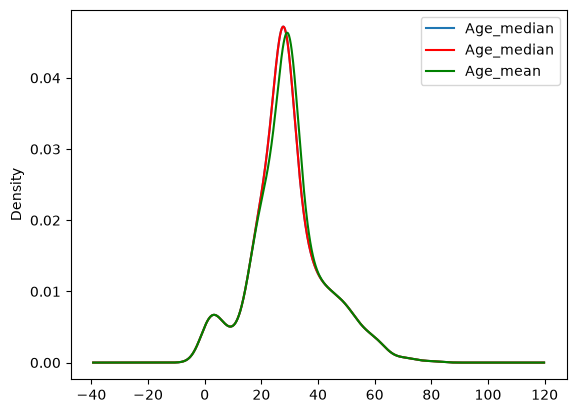

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original varibale  distribution
X_train['Age_median'].plot(kind='kde', ax=ax )

# Variable imputed with median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# Variable imputed with mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

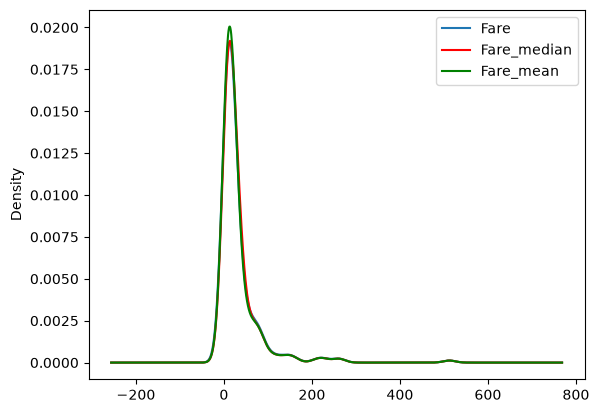

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original varibale  distribution
X_train['Fare'].plot(kind='kde', ax=ax )

# Variable imputed with median
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# Variable imputed with mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')


In [30]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.657433,17.672035
Age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,60.700688,59.728510
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Fare_median,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375
Fare_mean,70.082085,2761.031435,17.672035,59.728510,56.282518,2621.232375,2637.012482


<Axes: >

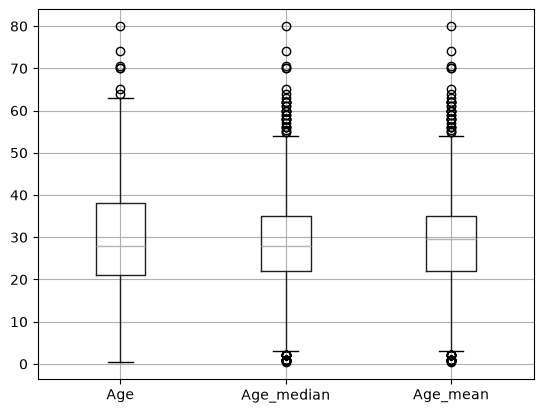

In [31]:
X_train[["Age", "Age_median", "Age_mean"]].boxplot()

<Axes: >

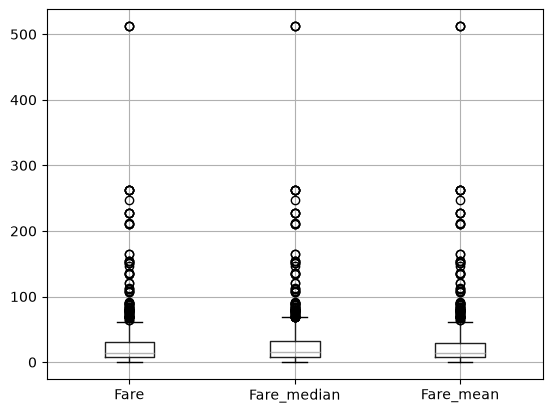

In [32]:
X_train[["Fare", "Fare_median", "Fare_mean"]].boxplot()

Using Scikit Learn

In [53]:
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
imputer1 = SimpleImputer(strategy="median")
imputer2 = SimpleImputer(strategy="mean")

In [55]:
trf = ColumnTransformer([
    ("imputer1", imputer1, ["Age"]),
    ("imputer2", imputer2, ["Fare"])
], remainder="passthrough")

In [56]:
trf

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [57]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [58]:

trf.named_transformers_['imputer1'].statistics_

array([28.])

In [59]:
trf.named_transformers_['imputer2'].statistics_


array([32.51778772])

In [60]:
X_train = trf.transform(X_test)
X_test = trf.transform(X_test)

In [61]:
X_train

array([[ 28.        ,  15.2458    ,   2.        ],
       [ 31.        ,  10.5       ,   0.        ],
       [ 20.        ,   7.925     ,   0.        ],
       [  6.        ,  33.        ,   1.        ],
       [ 14.        ,  11.2417    ,   1.        ],
       [ 26.        ,  78.85      ,   0.        ],
       [ 28.        ,   7.75      ,   0.        ],
       [ 16.        ,  18.        ,   2.        ],
       [ 16.        ,   7.75      ,   0.        ],
       [ 19.        ,  26.2833    ,   2.        ],
       [ 37.        ,  53.1       ,   1.        ],
       [ 44.        ,   8.05      ,   0.        ],
       [ 28.        ,  25.4667    ,   4.        ],
       [ 30.        ,   7.225     ,   0.        ],
       [ 36.        ,  13.        ,   0.        ],
       [ 16.        ,  39.4       ,   1.        ],
       [ 42.        ,  52.5542    ,   1.        ],
       [ 28.        ,   7.8292    ,   0.        ],
       [ 27.        ,  13.        ,   0.        ],
       [ 47.        ,  52.     